# **Connect to GEE**

In [2]:
!pip install -q --upgrade --pre xee
!pip install -q -U geemap

In [3]:
import ee

In [4]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-amirhosseinahrari',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


# **Study Area**

In [5]:
import geemap

In [6]:
hansen = (
    ee.Image("UMD/hansen/global_forest_change_2025_v1_13")
)

wildfire = (
    hansen.select('loss').eq(1).And(
        hansen.select('lossyear').eq(23)
    )
)


In [7]:
map = geemap.Map(basemap = 'SATELLITE')
map.addLayer(wildfire, {},'wildfire')
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [8]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -123.674469,
                          57.944743
                        ],
                        [
                          -123.674469,
                          58.148243
                        ],
                        [
                          -123.228149,
                          58.148243
                        ],
                        [
                          -123.228149,
                          57.944743
                        ],
                        [
                          -123.674469,
                          57.944743
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

# **Sentinel-2 Image Collection**

In [11]:
sen2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate('2022','2025')
    .filterBounds(roi)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',20))
    .linkCollection(
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"),
        'probability'
    )
)

In [13]:
def nbr(img):
  clean_pixel = img.select('probability').lt(20)
  sr_bands = img.select('B.*').multiply(0.0001)
  index = sr_bands.normalizedDifference(['B8','B12']).rename('nbr')
  return index.updateMask(clean_pixel).copyProperties(img,['system:time_start'])


In [14]:
sen2_nbr = sen2.map(nbr)

# **to Xarray**

In [16]:
from xee import helpers
from shapely.geometry import shape
import xarray as xr

In [17]:
sen2.first().select('B1').projection().crs()

In [18]:
grid = helpers.fit_geometry(
    geometry = shape(roi.getInfo()),
    grid_crs = 'EPSG:32610',
    grid_scale = (20, -20)
)

In [19]:
ds = xr.open_dataset(
    sen2_nbr,
    engine = 'ee',
    **grid
)

In [21]:
ds = ds.sortby('time') * 1

# **Burn Severity Analysis**

In [29]:
prefire = ds.sel(time = '2022').mean(dim = 'time')
postfire = ds.sel(time = '2024').mean(dim = 'time')
dnbr = prefire - postfire

In [23]:
import matplotlib.pyplot as plt

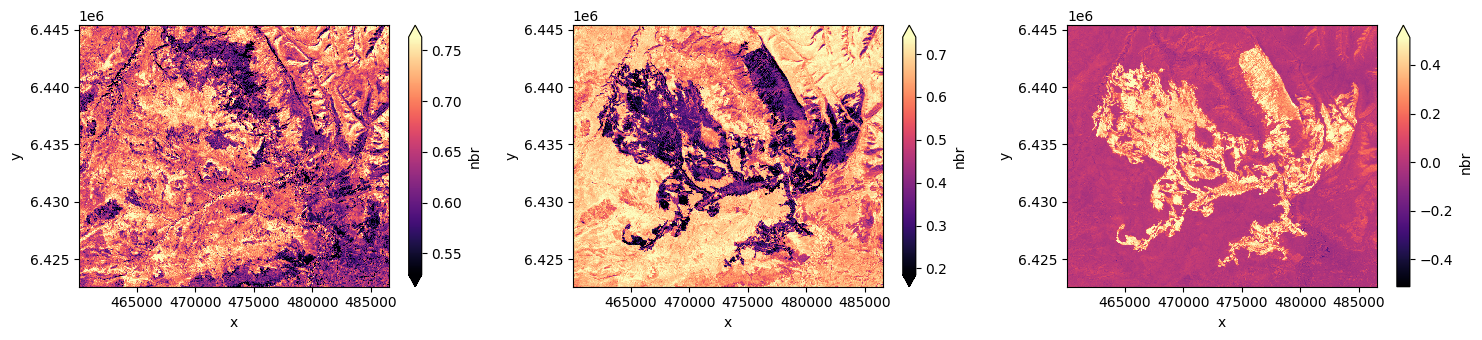

In [31]:
fig, ax = plt.subplots(1, 3, figsize = (15, 3.5))

prefire.nbr.plot(ax = ax[0], cmap = 'magma', robust = True)
postfire.nbr.plot(ax = ax[1], cmap = 'magma', robust = True)
dnbr.nbr.plot(ax = ax[2], cmap = 'magma', robust = True)

plt.tight_layout()

In [32]:
dnbr_clip = dnbr.clip(0,1)

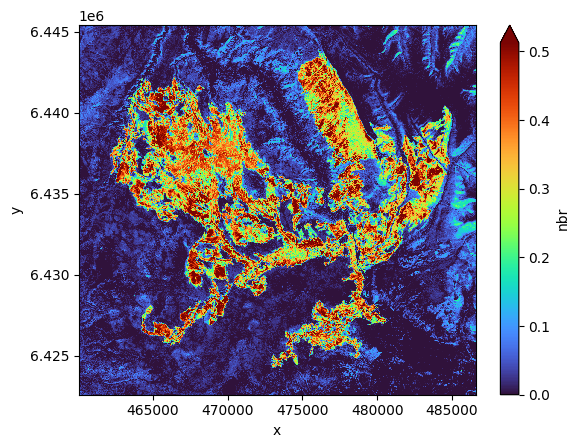

In [33]:
dnbr_clip.nbr.plot(robust = True, cmap = 'turbo')

In [36]:
burn_sev = xr.where(
    dnbr_clip.nbr < 0.1, 0,
    xr.where(
    dnbr_clip.nbr < 0.27, 1,
    xr.where(
    dnbr_clip.nbr < 0.44, 2,
    xr.where(
    dnbr_clip.nbr < 0.66, 3,  4
    ))))

In [38]:
import numpy as np

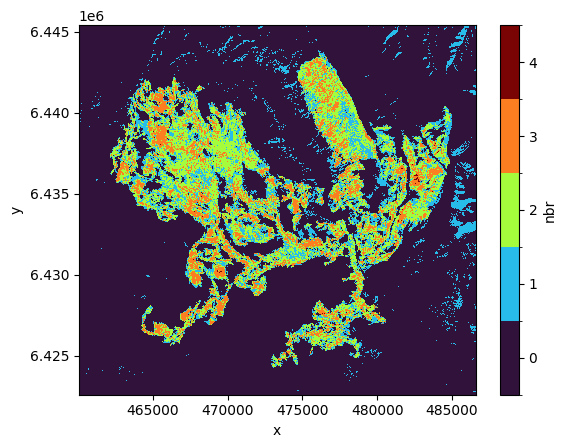

In [40]:
burn_sev.plot(cmap = 'turbo', levels = np.arange(-0.5, 5, 1),
              cbar_kwargs = {'ticks': range(5)})

In [47]:
for i in np.unique(burn_sev.values):
  class_area = (burn_sev == i).astype(int).sum(dim = ['x','y']).item() * ((20 * 20)/1e6)
  print(f'class {i}: {np.round(class_area,2)} km2')

class 0: 439.49 km2
class 1: 59.06 km2
class 2: 70.83 km2
class 3: 36.11 km2
class 4: 0.23 km2
